In [74]:
from utility.plot_from_hdf5 import plot_from_hdf5
from utility.my_colors import palette_dark, palette_light
from utility.contour_scatter_plot import contour_scatter_plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast

from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde

RESULTS_PATH = "data/results.csv"
FIT_PARAMS_PATH = "data/fit_params.csv"
DETAILS_PATH = "data/result_details.csv"
RELEVANT_RESULTS_PATH = "data/relevant_results.csv"

plt.rcdefaults()

settings = {
        'font.size':16,
        # 'xtick.direction':'in', 
#         # 'xtick.minor.visible':True,
        # 'xtick.top':True,
        # 'ytick.direction':'in', 
#         # 'ytick.minor.visible':True,
        # 'ytick.right':True,
        'xtick.major.size':5.0,
        'xtick.minor.size':2.0,
        'ytick.major.size':5.0,
        'ytick.minor.size':2.0,
        'legend.frameon':False,
        # 'mathtext.fontset':'stix',
        # 'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings)

In [75]:
results = pd.read_csv(RELEVANT_RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186890 entries, 39628261600268308 to 39627768828270015
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   rew_civ                  186890 non-null  float64
 1   rew_nv                   186890 non-null  float64
 2   rew_lya                  186890 non-null  float64
 3   snr_1700A                186888 non-null  float64
 4   snr_civ                  186890 non-null  float64
 5   snr_nv                   186890 non-null  float64
 6   snr_lya                  186890 non-null  float64
 7   pixel_used_civ           186890 non-null  float64
 8   pixel_used_blue_end_lya  186890 non-null  float64
 9   continuum_redchi         186890 non-null  float64
 10  z                        186890 non-null  float64
 11  zerr                     186890 non-null  float64
 12  civ_1549_flux            186890 non-null  float64
 13  civ_1549_flux_ivar       186890 non-n

### Check the subsequent samples like in Hamann
Objects that were processed (i.e. those from the initial SQL query) satisfy
`(zp.z BETWEEN 2.2 AND 4.38) AND (zp.zwarn=0) AND (agn.civ_1549_flux>0) AND (zp.spectype='QSO') AND zp.zcat_primary`

#### Full sample
- 2 < z 3.4 (lowest values are 2.2 not 2)
- warning=False which includes: SNR CIV > 2.5, continuum redchi2 < 2, all REW > 0 and not null, CIV at least 70% pixel used, Lya at least 65% pixel used on left side, z flux is larger 0 and not null

In [4]:
full = results[(results["z"] > 2) & (results["z"] < 3.4)].copy()
full["Sample"] = "Full"
full_idx = full.index
full

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,30.873547,79.327994,1578.572653,1755.868659,4467.502691,3253.396449,3251.881116,2260.575301,0.249399,Full
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,39.221570,80.179306,702.093410,373.690555,886.189289,5004.121189,4996.055063,2496.704981,0.238525,Full
39627901502489216,61.661126,50.066402,56.991357,0.736838,6.510926,4.934822,8.353253,0.962441,0.832898,0.150371,...,51.046492,63.236045,238.614723,241.211185,280.171174,5395.436113,5387.128039,4360.419360,0.234584,Full
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,67.106677,30.577277,908.245722,1909.709200,696.782583,7004.388592,6992.688130,3046.948259,0.324565,Full
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,52.529956,42.194407,881.968932,850.503658,742.675782,7365.153111,7353.267331,4962.357216,0.226158,Full
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628053415987103,118.962903,49.831986,92.167040,0.680706,2.613462,0.727741,1.646045,0.920596,0.889807,0.038240,...,45.596857,100.022424,84.395460,41.496963,78.308778,4527.744460,4535.865791,4139.097371,0.231864,Full
39627983115257786,52.601683,27.833232,38.173872,0.953028,8.233751,6.199389,12.435801,0.997835,0.828916,0.280892,...,33.765478,41.641763,641.849498,428.851538,603.353178,6748.325156,6737.115628,5221.039957,0.242868,Full
39627926517322439,88.433732,33.716419,139.284764,0.519953,12.028317,5.543115,18.376339,0.950108,0.840580,0.050119,...,32.918452,138.756640,197.663768,105.628622,450.723156,2341.986219,2341.278198,2033.014791,0.270749,Full


#### W3-detected
- SNR(W3) > 3

In [5]:
w3_detected = full.query("snr_w3 > 3").copy()
w3_detected["Sample"] = "W3 detected"
w3_detected_idx = w3_detected.index
w3_detected

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,30.873547,79.327994,1578.572653,1755.868659,4467.502691,3253.396449,3251.881116,2260.575301,0.249399,W3 detected
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,39.221570,80.179306,702.093410,373.690555,886.189289,5004.121189,4996.055063,2496.704981,0.238525,W3 detected
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,67.106677,30.577277,908.245722,1909.709200,696.782583,7004.388592,6992.688130,3046.948259,0.324565,W3 detected
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,52.529956,42.194407,881.968932,850.503658,742.675782,7365.153111,7353.267331,4962.357216,0.226158,W3 detected
39627779037202942,41.069234,52.377690,17.228492,0.655766,2.868326,2.217354,3.632044,0.950588,0.879581,0.106126,...,43.567645,18.367051,101.499588,172.368010,57.564280,5503.989179,5494.918240,1743.896308,0.253387,W3 detected
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632961531806138,68.280006,61.465376,127.422601,0.520987,3.496122,3.179693,4.785442,0.933602,0.887892,0.083141,...,74.313305,145.025455,68.275819,67.038541,138.726613,5072.738838,5078.892571,6232.192289,0.262452,W3 detected
39627915016539584,32.306415,36.275146,19.276486,0.970341,10.217814,8.539332,6.160885,0.908676,0.783715,0.737209,...,45.084766,24.134494,616.826902,850.030266,465.566363,6061.770891,6051.918394,4207.913901,0.235826,W3 detected
39628382106812614,36.539355,31.760665,50.060707,0.803729,6.521420,5.596410,12.129493,0.982340,0.790588,0.060873,...,30.639997,50.611621,319.207859,328.347364,525.811885,4435.790432,4436.779084,2583.511499,0.234770,W3 detected


#### ERQs
- z-W3 > 3.9

In [6]:
erq = w3_detected[w3_detected["z-w3"] > 3.9].copy()
erq["Sample"] = "ERQ"
erq_idx = erq.index
erq

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39627779037202942,41.069234,52.377690,17.228492,0.655766,2.868326,2.217354,3.632044,0.950588,0.879581,0.106126,...,43.567645,18.367051,101.499588,172.368010,57.564280,5503.989179,5494.918240,1743.896308,0.253387,ERQ
39627699790024199,54.296104,49.135866,70.136264,0.736011,6.149229,4.306026,10.850016,0.966667,0.767742,0.470200,...,46.295448,72.000721,269.308325,270.468872,392.309264,4810.223967,4802.497872,2880.468972,0.301892,ERQ
39628123985153993,125.232001,59.333197,394.957945,0.566372,3.777197,2.119422,10.053563,0.897216,0.875598,0.065059,...,74.504683,408.076060,74.910659,42.058782,280.985594,2736.066292,2736.942211,2436.999237,0.354027,ERQ
39628410783271554,89.148791,37.180647,54.512249,0.729147,4.183250,1.920362,4.650294,0.980296,0.872928,0.011805,...,41.075506,58.197953,250.329587,160.406223,245.082476,5333.544384,5324.768893,5147.189275,0.238072,ERQ
39628017118484156,69.084521,30.747853,65.695091,0.735615,3.597611,1.550206,2.602071,0.937238,0.842920,0.005644,...,38.555854,71.679024,109.690129,58.266969,128.186091,3098.068322,3101.563283,2681.904379,0.237146,ERQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628257213028100,58.748484,39.964032,95.143695,0.455924,3.710882,0.931673,4.008748,0.887133,0.879093,0.037589,...,38.808723,103.421342,57.212552,37.382676,88.044224,1544.838621,1548.736996,1742.937950,0.193428,ERQ
39627981827606141,43.335297,37.726595,33.696240,0.820696,3.186362,1.079839,3.451561,0.958025,0.903846,0.022352,...,31.636476,33.417698,93.913667,85.048706,76.108319,5886.729163,5877.097949,3141.389888,0.227888,ERQ
39627567950466529,27.040848,9.697804,36.252028,0.582844,4.036805,2.470379,8.181252,0.917526,0.747706,0.079300,...,22.278524,49.139704,204.505576,84.783761,328.567986,7352.573994,7364.694387,4137.069754,0.296886,ERQ


#### Core ERQs
- REW(CIV) > 100

In [7]:
core_erq = erq[erq["rew_civ"] > 100]
core_erq_idx = core_erq.index
core_erq

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628123985153993,125.232001,59.333197,394.957945,0.566372,3.777197,2.119422,10.053563,0.897216,0.875598,0.065059,...,74.504683,408.076060,74.910659,42.058782,280.985594,2736.066292,2736.942211,2436.999237,0.354027,ERQ
39628072797866727,470.986602,93.509273,315.010605,0.552134,4.489033,1.061074,3.148873,0.953431,0.923497,0.011409,...,121.484755,337.753605,137.813298,37.926078,130.347061,3531.641976,3526.612645,2230.649285,0.241008,ERQ
39627891113201923,112.219588,62.672895,99.054101,0.606324,5.955274,2.710882,7.278569,0.983945,0.908163,0.016740,...,64.175805,97.136269,168.987387,121.849523,196.661733,7779.767027,7766.704920,2365.939453,0.372357,ERQ
39627780903669053,140.798530,249.117161,53.101180,0.543534,4.137893,5.718557,1.320132,0.901119,0.854470,0.004901,...,299.202272,138.779761,63.974277,105.536849,22.320187,2529.297899,2530.247288,6773.692334,0.351498,ERQ
39628396275177020,171.882397,39.498231,197.261087,0.697958,4.498471,0.809909,6.562073,0.978599,0.891540,0.002679,...,29.507003,190.096757,177.606102,60.731517,310.860502,4464.904177,4472.554377,1887.898275,0.235758,ERQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632971719774209,107.142013,40.204052,90.573330,0.451184,2.535676,0.928699,2.889068,0.950237,0.883905,0.026021,...,52.817816,106.850193,82.582710,35.124023,81.524699,6280.214439,6276.672312,3343.599854,0.244395,ERQ
39627606353513953,262.600709,133.373283,372.368041,0.875102,4.632945,2.508304,5.879460,0.912281,0.878049,0.042191,...,143.146019,404.085167,68.373912,51.797066,141.663679,1881.783099,1883.899711,1873.157476,0.352662,ERQ
39627897656312134,177.743800,54.117060,459.072967,1.142572,3.396098,0.698038,2.474661,0.840580,0.902965,0.022673,...,48.875308,509.715404,46.574391,15.453301,130.559180,1368.113618,1369.526758,1742.997973,0.372517,ERQ


#### REW(CIV) > 100

In [8]:
large = full.query("rew_civ > 100").copy()
large_idx = large.index
large["Sample"] = "Large"
large

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628412662323165,161.601504,66.853313,24.886163,0.661391,5.145252,2.287900,1.508265,0.990172,0.836066,0.051041,...,97.918390,46.506675,312.551058,172.708966,66.286349,6157.448766,6147.276882,3865.514543,0.231917,Large
39628481855754778,149.066299,45.077878,88.992064,0.626327,4.060759,1.097277,2.594436,0.956190,0.881356,0.008430,...,52.837864,110.339125,111.886956,36.090498,72.030086,4415.217735,4407.751356,4426.295422,0.248055,Large
39627985698953905,134.089950,59.402374,94.582893,0.558191,8.832818,2.819567,7.060071,0.993135,0.884615,0.168216,...,59.768305,98.564059,528.413473,297.357835,484.507598,5025.185630,5016.763647,4696.221716,0.242982,Large
39627497754594111,107.996366,35.047851,123.960369,0.423711,6.565238,1.992941,7.510495,0.963325,0.925824,0.083516,...,35.319866,123.191551,233.432668,104.124874,380.926539,3380.669722,3376.700628,2172.249027,0.275029,Large
39628495797618139,181.144207,35.396888,159.440111,0.747491,3.404237,1.493232,2.868796,0.917595,0.863524,0.026513,...,66.708317,202.723108,94.571626,21.993908,100.743943,5329.609541,5320.673323,5787.762262,0.245590,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39627766093584889,100.659055,34.724141,74.987139,0.694299,4.940178,1.772425,5.475085,0.967442,0.888601,0.020050,...,44.420492,81.118414,197.145220,88.004187,194.620464,5189.891896,5181.619930,2452.828302,0.229893,Large
39628337403923861,104.989620,31.105850,101.069486,0.652475,4.819678,0.978631,3.843473,0.977612,0.889197,0.066478,...,31.079209,98.970324,208.883345,87.152896,291.297392,4813.784514,4805.810946,2203.319066,0.240380,Large
39628259347926729,113.953401,41.878910,118.952360,0.715565,4.402226,1.670195,2.452027,0.949398,0.908602,0.030174,...,55.373829,144.621351,107.152716,41.973889,120.600626,4294.859877,4297.107847,6293.627562,0.282238,Large


#### ERQ-like

In [37]:
# erq_like = results[(results["flux_z"] > 0) & (~results["flux_z"].isna()) & ((results["z"] >= 3.4) | (results["z"] <= 2)) & (results["snr_w3"] > 3) & (results["z-w3"] > 3.9) & (results["rew_civ"] > 100)]
# erq_like

### Plots

In [10]:
full = full.drop(index=["39627636372146550"])  # super large CIV REW

#### Evaluate method

#### Histogram: REW colored by object type

In [34]:
# histplot_df = full.copy()

# histplot_df["Sample"] = "Full"
# temp1 = erw

# for elem in histplot_df.index:
#     # if elem in core_erq_idx: 
#     if elem in erq_idx:
#         histplot_df.loc[elem,"Sample"] = "ERQ"
#     elif elem in w3_detected_idx:
#         histplot_df.loc[elem,"Sample"] = "W3 detected"
histplot_df = pd.concat([full,w3_detected,erq]).reset_index(drop=False)

histplot_df["Sample"].value_counts()

hue_order = ["Full", "W3 detected", "ERQ"]
hist_palette = ["gray", palette_dark[2], palette_dark[0]]

[]

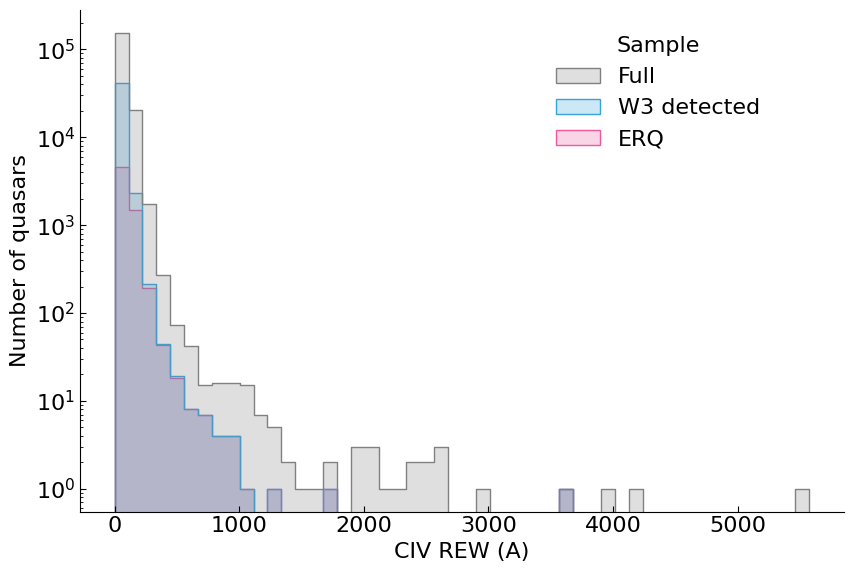

In [ ]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

civ_histplot = histplot_df[["rew_civ", "fwhm_civ","Sample"]].copy()

# civ_histplot["rew_civ"] = civ_histplot["rew_civ"].clip(upper=1000)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=civ_histplot, x="rew_civ", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")

# xticks = list(range(0,1001,200))#ax.get_xticks()
# ax.set_xticks(xticks)
# xticklabels = [str(int(t)) for t in xticks]
# xticklabels[-1] = "1000+"
# ax.set_xticklabels(xticklabels)
# ax.set_xlim()

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("CIV REW (A)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

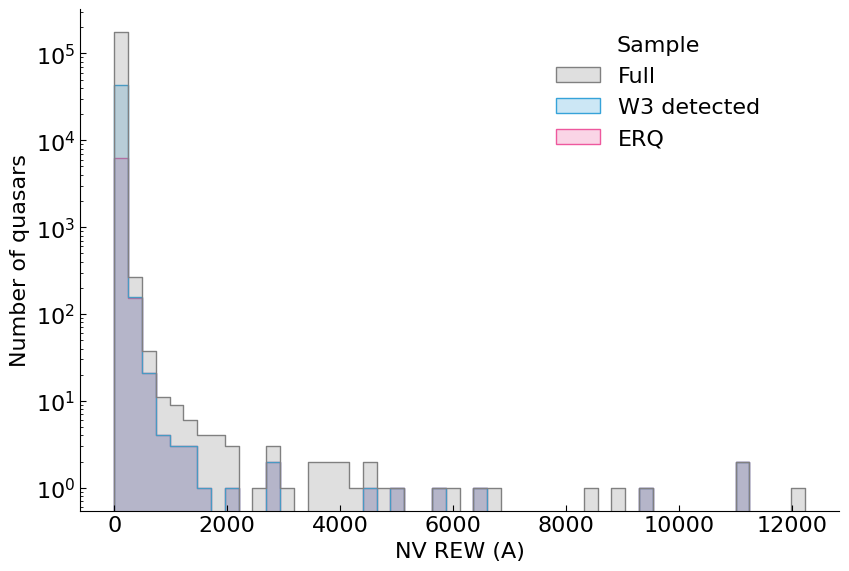

In [228]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

nv_histplot = histplot_df[["rew_nv","fwhm_nv","Sample"]].copy()

# nv_histplot["rew_nv"] = nv_histplot["rew_nv"].clip(upper=1000)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=nv_histplot, x="rew_nv", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")

# plt.xlim(-5,1005)

# xticks = list(range(0,1001,200))#ax.get_xticks()
# ax.set_xticks(xticks)
# xticklabels = [str(int(t)) for t in xticks]
# xticklabels[-1] = "1000+"
# ax.set_xticklabels(xticklabels)

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("NV REW (A)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

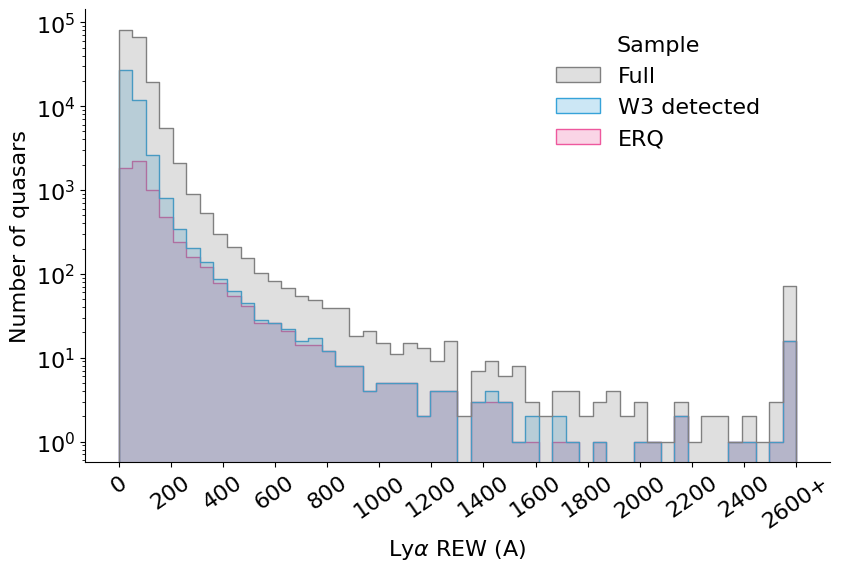

In [13]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

lya_histplot = histplot_df[["rew_lya","fwhm_lya","Sample"]].copy()#

lya_histplot["rew_lya"] = lya_histplot["rew_lya"].clip(upper=2600)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=lya_histplot, x="rew_lya", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")


xticks = list(range(0,2601,200))#ax.get_xticks()
ax.set_xticks(xticks)
xticklabels = [str(int(t)) for t in xticks]
xticklabels[-1] = "2600+"
ax.set_xticklabels(xticklabels,rotation=35)


sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel(r"Ly$\alpha$ REW (A)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

#### Histogram: FWHM colored by object type

[]

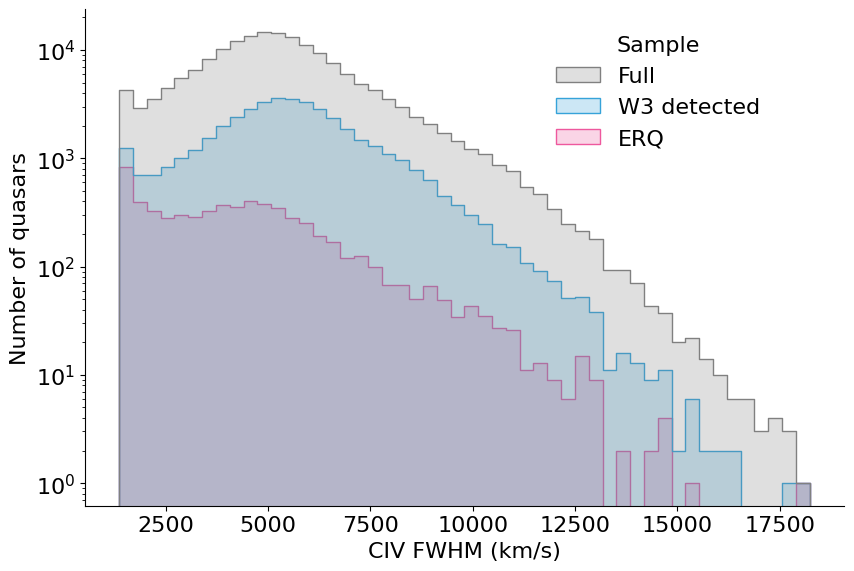

In [14]:
g = sns.displot(data=civ_histplot, x="fwhm_civ", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)

ax = g.ax

plt.yscale("log")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("CIV FWHM (km/s)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

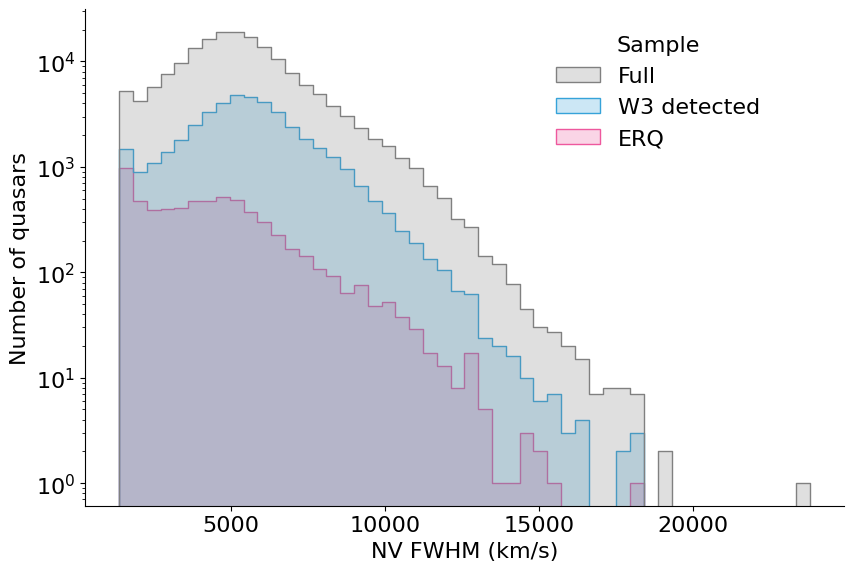

In [15]:
g = sns.displot(data=nv_histplot, x="fwhm_nv", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)

ax = g.ax

plt.yscale("log")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("NV FWHM (km/s)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

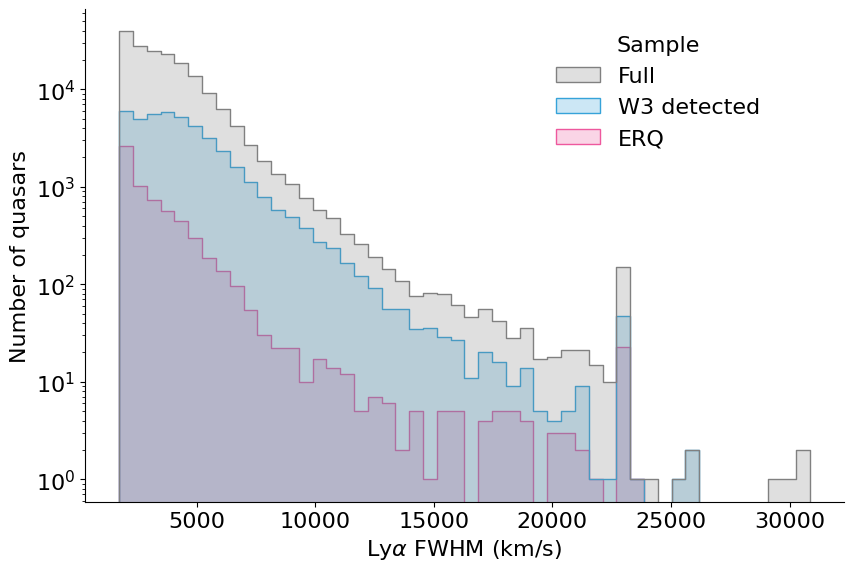

In [16]:
g = sns.displot(data=lya_histplot, x="fwhm_lya", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)

ax = g.ax

plt.yscale("log")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel(r"Ly$\alpha$ FWHM (km/s)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

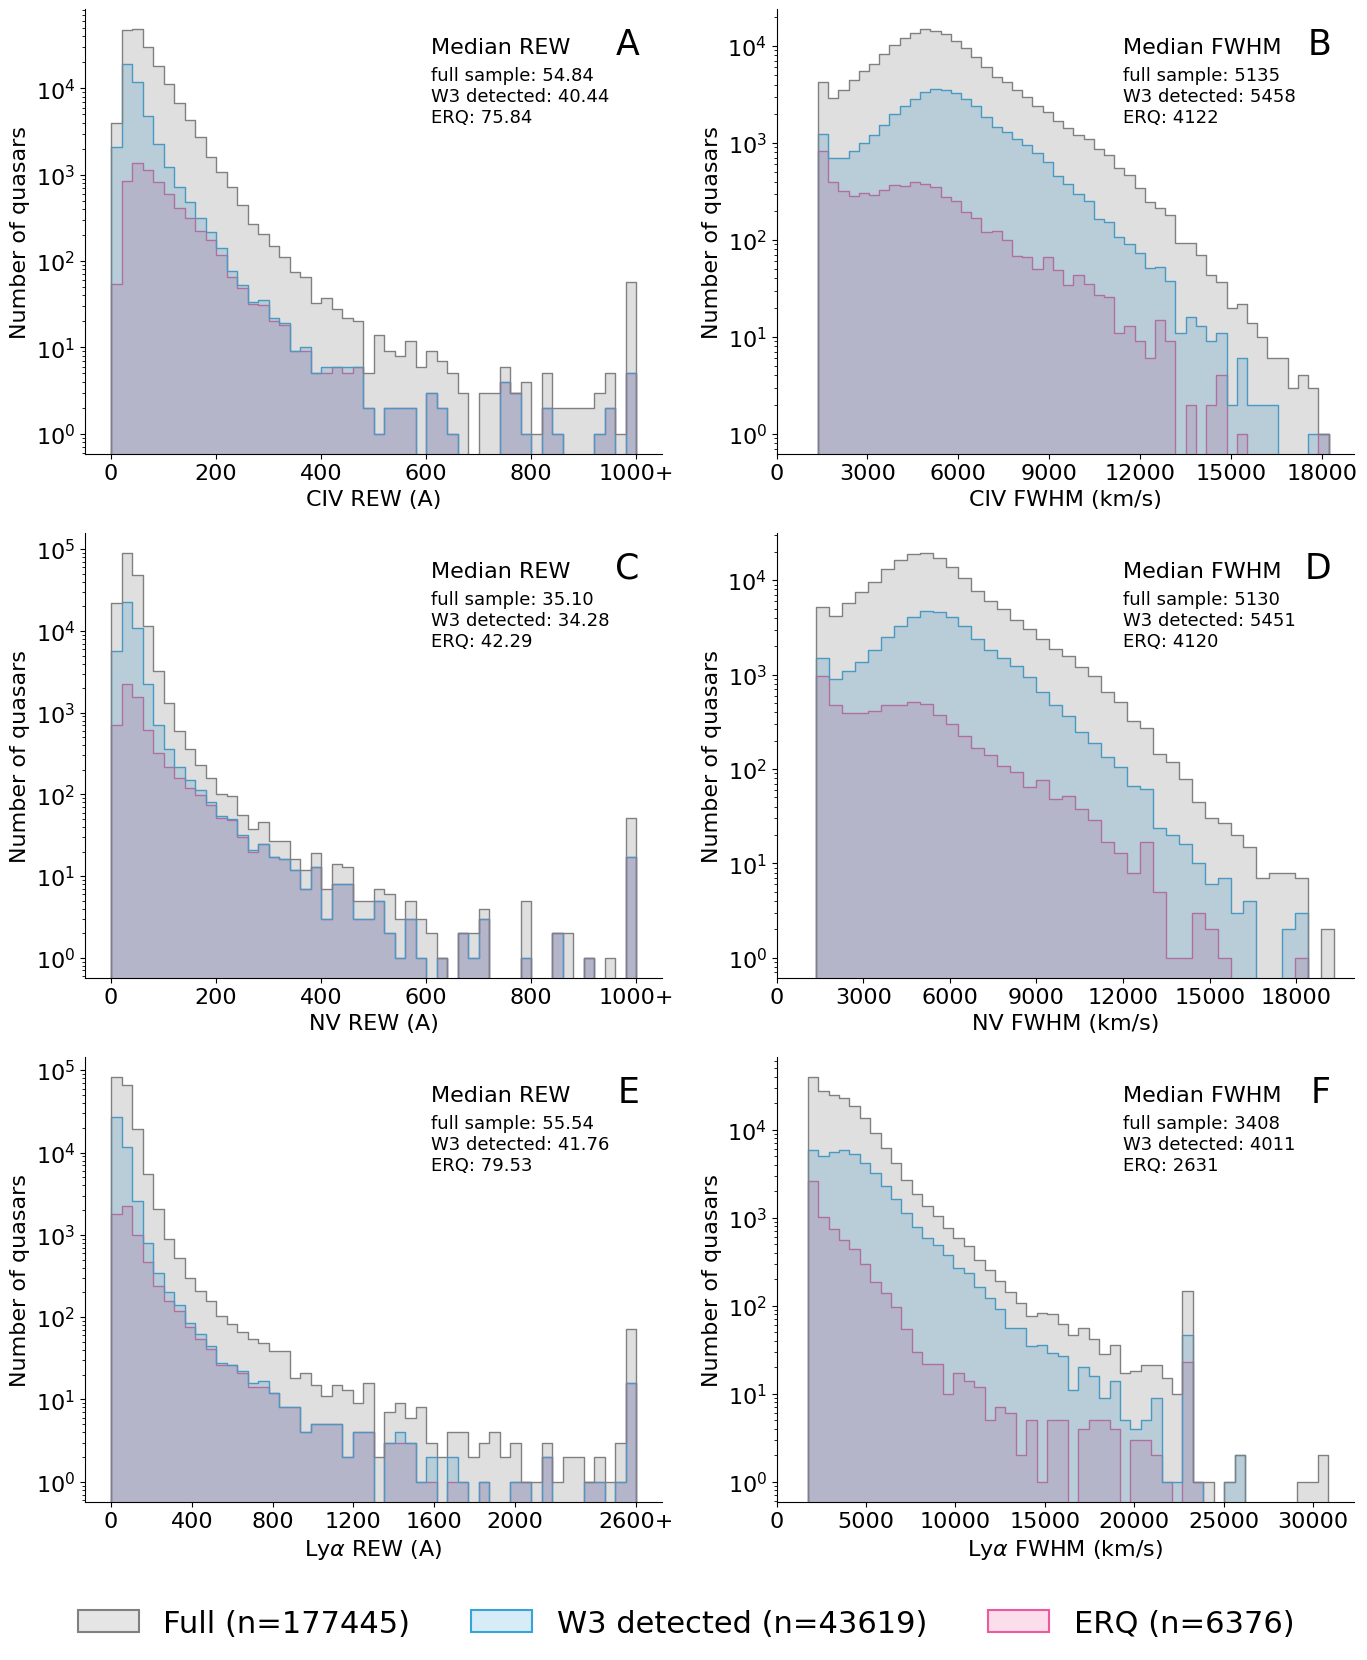

In [ ]:
fig, ax = plt.subplots(3,2,figsize=(14,16))


## CIV REW [0,0]

sns.histplot(data=civ_histplot, x="rew_civ", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[0,0],legend=False)

ax[0,0].set_yscale("log")

xticks_00 = list(range(0,1001,200))
ax[0,0].set_xticks(xticks_00)
xticklabels_00 = [str(int(t)) for t in xticks_00]
xticklabels_00[-1] = "1000+"
ax[0,0].set_xticklabels(xticklabels_00)

ax[0,0].set_xlabel("CIV REW (A)")
ax[0,0].set_ylabel("Number of quasars")
ax[0,0].spines[['right', 'top']].set_visible(False)

ax[0,0].text(0.6,0.9,f"Median REW",transform=ax[0,0].transAxes,fontsize=16)
ax[0,0].text(0.6,0.7,f"full sample: {full['rew_civ'].median():.2f}\nW3 detected: {w3_detected['rew_civ'].median():.2f}\nERQ: {erq['rew_civ'].median():.2f}\n",transform=ax[0,0].transAxes,fontsize=13)

## CIV FWHM [0,1]

sns.histplot(data=civ_histplot, x="fwhm_civ", hue="Sample", bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[0,1],legend=False)

ax[0,1].set_yscale("log")

xticks_01 = list(range(0,18001,3000))
ax[0,1].set_xticks(xticks_01)

ax[0,1].set_xlabel("CIV FWHM (km/s)")
ax[0,1].set_ylabel("Number of quasars")
ax[0,1].spines[['right', 'top']].set_visible(False)

ax[0,1].text(0.6,0.9,f"Median FWHM",transform=ax[0,1].transAxes,fontsize=16)
ax[0,1].text(0.6,0.7,f"full sample: {full['fwhm_civ'].median():.0f}\nW3 detected: {w3_detected['fwhm_civ'].median():.0f}\nERQ: {erq['fwhm_civ'].median():.0f}\n",transform=ax[0,1].transAxes,fontsize=13)

## NV REW [1,0]

sns.histplot(data=nv_histplot, x="rew_nv", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[1,0],legend=False)

ax[1,0].set_yscale("log")

xticks_10 = list(range(0,1001,200))
ax[1,0].set_xticks(xticks_10)
xticklabels_10 = [str(int(t)) for t in xticks_10]
xticklabels_10[-1] = "1000+"
ax[1,0].set_xticklabels(xticklabels_10)

ax[1,0].set_xlabel("NV REW (A)")
ax[1,0].set_ylabel("Number of quasars")
ax[1,0].spines[['right', 'top']].set_visible(False)

ax[1,0].text(0.6,0.9,f"Median REW",transform=ax[1,0].transAxes,fontsize=16)
ax[1,0].text(0.6,0.7,f"full sample: {full['rew_nv'].median():.2f}\nW3 detected: {w3_detected['rew_nv'].median():.2f}\nERQ: {erq['rew_nv'].median():.2f}\n",transform=ax[1,0].transAxes,fontsize=13)

## NV FWHM [1,1]

sns.histplot(data=nv_histplot, x="fwhm_nv", hue="Sample", bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[1,1],legend=False)

ax[1,1].set_yscale("log")

xticks_11 = list(range(0,18001,3000))
ax[1,1].set_xticks(xticks_11)

lower_x_11, _ = ax[1,1].get_xlim()
ax[1,1].set_xlim(lower_x_11, 20000)

ax[1,1].set_xlabel("NV FWHM (km/s)")
ax[1,1].set_ylabel("Number of quasars")
ax[1,1].spines[['right', 'top']].set_visible(False)

ax[1,1].text(0.6,0.9,f"Median FWHM",transform=ax[1,1].transAxes,fontsize=16)
ax[1,1].text(0.6,0.7,f"full sample: {full['fwhm_nv'].median():.0f}\nW3 detected: {w3_detected['fwhm_nv'].median():.0f}\nERQ: {erq['fwhm_nv'].median():.0f}\n",transform=ax[1,1].transAxes,fontsize=13)

## LYA REW [2,0]

sns.histplot(data=lya_histplot, x="rew_lya", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[2,0],legend=False)

ax[2,0].set_yscale("log")

xticks_20 = list(range(0,2001,400))+[2600]
ax[2,0].set_xticks(xticks_20)
xticklabels_20 = [str(int(t)) for t in xticks_20]
xticklabels_20[-1] = "2600+"
ax[2,0].set_xticklabels(xticklabels_20)

ax[2,0].set_xlabel(r"Ly$\alpha$ REW (A)")
ax[2,0].set_ylabel("Number of quasars")
ax[2,0].spines[['right', 'top']].set_visible(False)

ax[2,0].text(0.6,0.9,f"Median REW",transform=ax[2,0].transAxes,fontsize=16)
ax[2,0].text(0.6,0.7,f"full sample: {full['rew_lya'].median():.2f}\nW3 detected: {w3_detected['rew_lya'].median():.2f}\nERQ: {erq['rew_lya'].median():.2f}\n",transform=ax[2,0].transAxes,fontsize=13)

## LYA FWHM [2,1]

sns.histplot(data=lya_histplot, x="fwhm_lya", hue="Sample", bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[2,1],legend=False)

ax[2,1].set_yscale("log")

ax[2,1].set_xlabel(r"Ly$\alpha$ FWHM (km/s)")
ax[2,1].set_ylabel("Number of quasars")
ax[2,1].spines[['right', 'top']].set_visible(False)

xticks_21 = ax[2,1].get_xticks()
ax[2,1].set_xticks([0]+xticks_21[:-1])

ax[2,1].text(0.6,0.9,f"Median FWHM",transform=ax[2,1].transAxes,fontsize=16)
ax[2,1].text(0.6,0.7,f"full sample: {full['fwhm_lya'].median():.0f}\nW3 detected: {w3_detected['fwhm_lya'].median():.0f}\nERQ: {erq['fwhm_lya'].median():.0f}\n",transform=ax[2,1].transAxes,fontsize=13)

## GLOBAL STYLE THINGS

# letters in upper right corner
labels = ['A', 'B', 'C', 'D', 'E', 'F']

for a, letter in zip(ax.flat, labels):
    a.text(
        0.96, 0.96, f"{letter}",
        transform=a.transAxes,
        ha='right', va='top',
        fontsize=25,
    )



# ax[0,0].text(
#         0.96, 0.96, f"Full sample median REW = {full['rew_civ'].median()}",
#         transform=a.transAxes,
#         ha='right', va='top',
#         fontsize=10,
#     )

# legend
handles = [
    Patch(
        facecolor=mcolors.to_rgba(c, alpha=0.2),  # transparent fill
        edgecolor=c,
        linewidth=1.5,
    )
    for c in hist_palette
]



leg = fig.legend(
    handles, labels_legend,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(handles),
    frameon=False,
    fontsize=22,
    markerscale=4
)


plt.tight_layout()

# plt.savefig("images/histograms_v1.svg")

plt.show()

In [34]:
full

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,30.873547,79.327994,1578.572653,1755.868659,4467.502691,3253.396449,3251.881116,2260.575301,0.249399,Full
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,39.221570,80.179306,702.093410,373.690555,886.189289,5004.121189,4996.055063,2496.704981,0.238525,Full
39627901502489216,61.661126,50.066402,56.991357,0.736838,6.510926,4.934822,8.353253,0.962441,0.832898,0.150371,...,51.046492,63.236045,238.614723,241.211185,280.171174,5395.436113,5387.128039,4360.419360,0.234584,Full
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,67.106677,30.577277,908.245722,1909.709200,696.782583,7004.388592,6992.688130,3046.948259,0.324565,Full
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,52.529956,42.194407,881.968932,850.503658,742.675782,7365.153111,7353.267331,4962.357216,0.226158,Full
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628053415987103,118.962903,49.831986,92.167040,0.680706,2.613462,0.727741,1.646045,0.920596,0.889807,0.038240,...,45.596857,100.022424,84.395460,41.496963,78.308778,4527.744460,4535.865791,4139.097371,0.231864,Full
39627983115257786,52.601683,27.833232,38.173872,0.953028,8.233751,6.199389,12.435801,0.997835,0.828916,0.280892,...,33.765478,41.641763,641.849498,428.851538,603.353178,6748.325156,6737.115628,5221.039957,0.242868,Full
39627926517322439,88.433732,33.716419,139.284764,0.519953,12.028317,5.543115,18.376339,0.950108,0.840580,0.050119,...,32.918452,138.756640,197.663768,105.628622,450.723156,2341.986219,2341.278198,2033.014791,0.270749,Full


In [22]:
len(civ_histplot[civ_histplot["Sample"]=="Full"])

177445

In [37]:
hue_order
labels_legend = [f"Full (n={len(full)})",f"W3 detected (n={len(w3_detected)})", f"ERQ (n={len(erq)})"]

In [20]:
full[["fwhm_civ","fwhm_nv","fwhm_lya"]].describe()

,fwhm_civ,fwhm_nv,fwhm_lya
count,177400.000000,177346.000000,177358.000000
mean,5345.673061,5341.747184,3847.425869
std,2069.283645,2070.355572,2025.266506
min,1367.210673,1365.329927,1742.625254
25%,4021.318813,4018.672102,2415.315973
50%,5135.252247,5129.526504,3407.591604
75%,6380.020705,6372.251249,4628.304305
max,18229.332175,23788.928605,30844.539955


In [21]:
(full["fwhm_civ"] > 2000).mean()

0.9613852179548592

#### i-W3 histogram

In [12]:
color_hist_df = w3_detected[w3_detected["rew_civ"]>100].copy()
color_hist_df["Sample"] = "REW(CIV) > 100"
color_hist_df = pd.concat([color_hist_df,w3_detected])[["z-w3","Sample"]]

# color_hist_df

[]

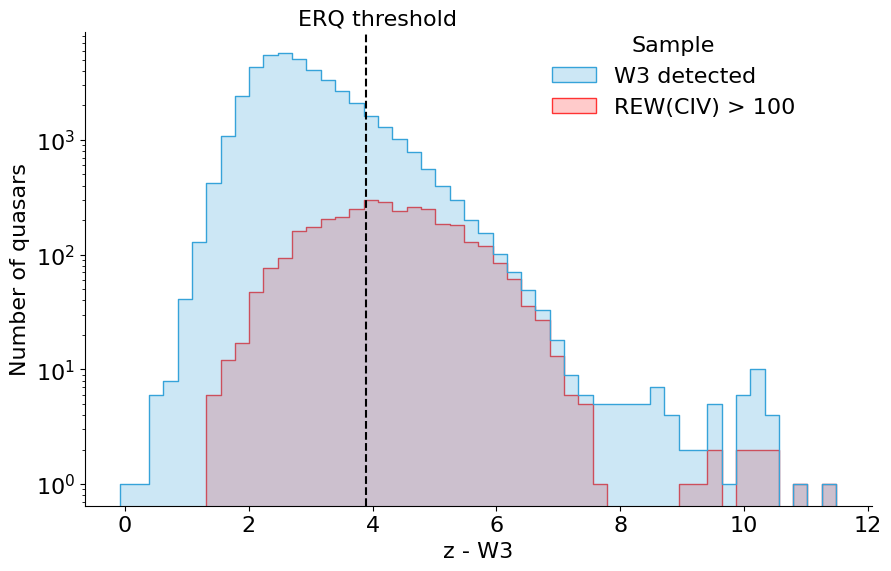

In [ ]:
g = sns.displot(data=color_hist_df, x="z-w3", hue="Sample",bins=50,element="step",hue_order=["W3 detected","REW(CIV) > 100"],palette=[palette_dark[2],palette_dark[5]],height=6,aspect=1.1)

plt.yscale("log")

plt.xlabel("z - W3")
plt.ylabel("Number of quasars")

plt.axvline(3.9,color="black",label="ERQ threshold",linestyle="--")
plt.text(2.8,10000,"ERQ threshold")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))

plt.tight_layout()

# plt.savefig("images/color_hist.svg")

plt.plot()

#### NV/CIV vs color

In [11]:
# dataframe where the subsets are not duplicate like for the histograms
w3_copy_df = w3_detected[["z-w3","flux_civ","flux_nv","flux_lya","rew_civ","kt80_civ","Sample","z"]].copy()
w3_copy_df["nv/civ"] = w3_copy_df["flux_nv"] / w3_copy_df["flux_civ"]
w3_copy_df["nv/lya"] = w3_copy_df["flux_nv"] / w3_copy_df["flux_lya"]

for elem in w3_copy_df.index:
    if w3_copy_df.loc[elem,"rew_civ"] > 100:
        w3_copy_df.loc[elem,"Sample"] = "REW(CIV) > 100"

w3_copy_df = w3_copy_df.reset_index()

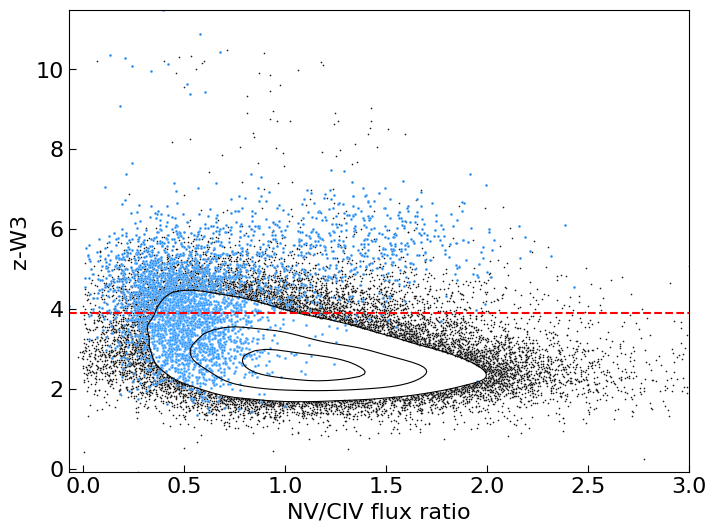

In [39]:
contour_scatter_plot(w3_copy_df,x="nv/civ",y="z-w3",upper_x_lim=3,x_label="NV/CIV flux ratio",y_label="z-W3",threshold_color="red",subsample_color="DodgerBlue")

In [28]:
w3_copy_df["rew_civ_log"] = np.log10(w3_copy_df["rew_civ"].values)

/tmp/ipykernel_20448/3947095523.py:1: RuntimeWarning: divide by zero encountered in log10
  w3_copy_df["rew_civ_log"] = np.log10(w3_copy_df["rew_civ"].values)


In [29]:
details = pd.read_csv(DETAILS_PATH,dtype={"targetid":"str"})
kt80_df = w3_copy_df[w3_copy_df["kt80_civ"].notna()].merge(details,on="targetid",how="left").set_index("targetid")#.drop(columns=["targetid_y"]).rename(columns={"targetid_x":"targetid"})

for idx in kt80_df.index:
    kt80_df.loc[idx,"accept_two_civ"] = ast.literal_eval(kt80_df.loc[idx,"line_fit_civ"])["accept_two"]

/tmp/ipykernel_20448/918213136.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  kt80_df.loc[idx,"accept_two_civ"] = ast.literal_eval(kt80_df.loc[idx,"line_fit_civ"])["accept_two"]


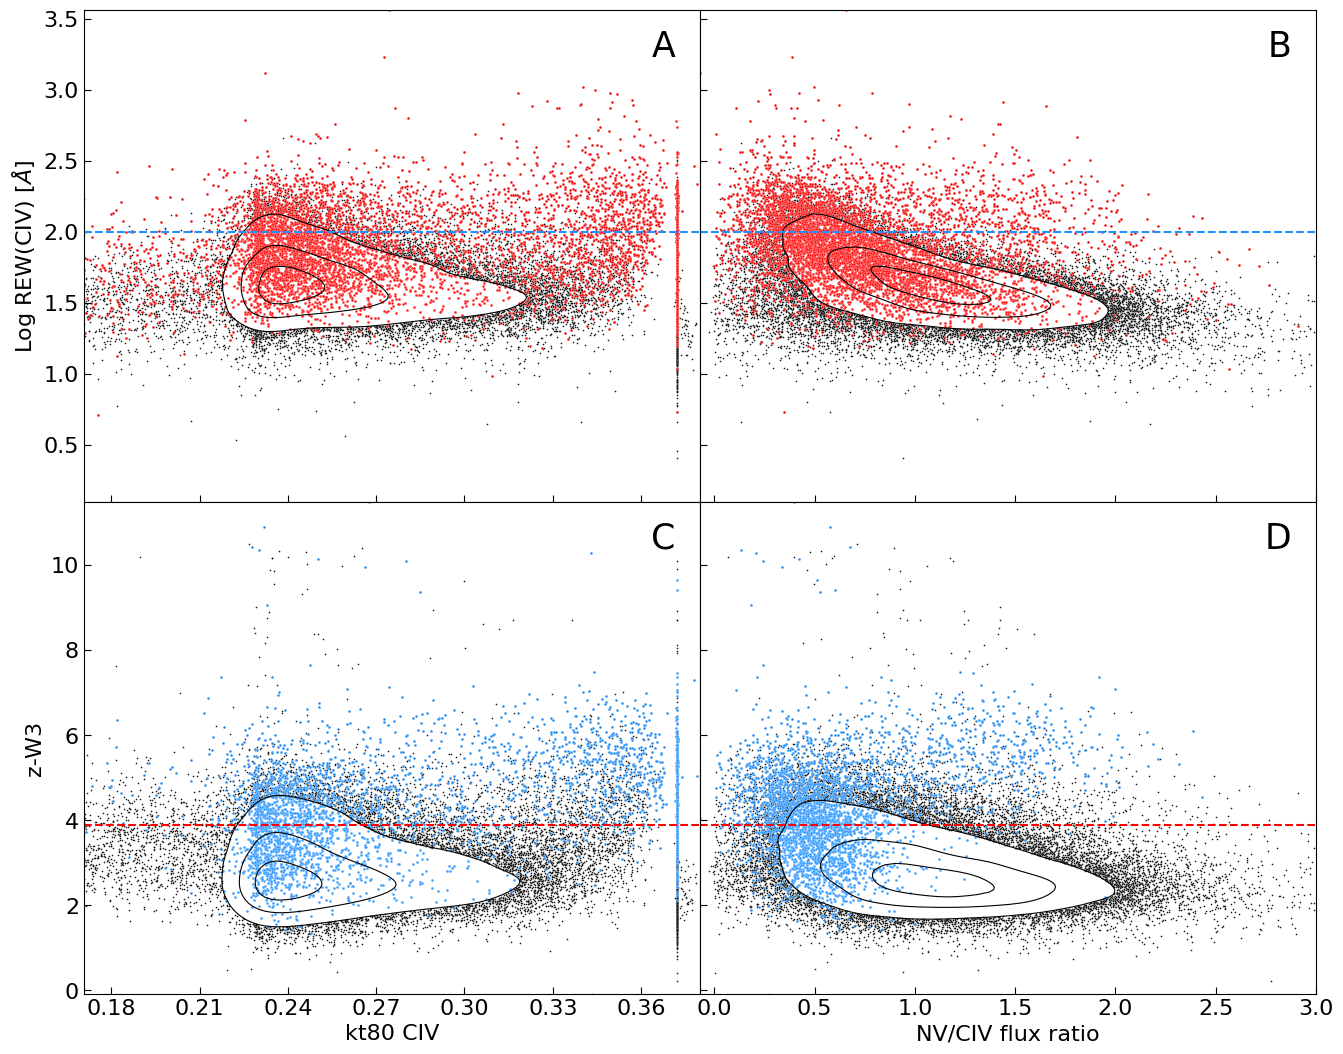

In [73]:
fig, axes = plt.subplots(2,2,figsize=(14,12),sharex="col",sharey="row")


contour_scatter_plot_v2(kt80_df[(kt80_df["accept_two_civ"]==True)&(np.isfinite(kt80_df["rew_civ_log"]))],x="kt80_civ",y="rew_civ_log",x_label="kt80 CIV",y_label=r"Log REW(CIV) [$\AA$]",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=2,y_threshold_label="Core ERQ threshold",upper_x_lim=0.38,ax=axes[0,0],second_df=kt80_df[kt80_df["accept_two_civ"]==False])

# sns.scatterplot(data=kt80_df[(kt80_df["kt80_civ"]>0.33)&(kt80_df["nv/civ"]>1.3)],x="kt80_civ",y="rew_civ_log",ax=axes[0,0],color="ForestGreen",s=5,alpha=0.9)



contour_scatter_plot(w3_copy_df[(np.isfinite(w3_copy_df["rew_civ_log"]))],x="nv/civ",y="rew_civ_log",upper_x_lim=3,x_label="NV/CIV flux ratio",y_label=r"Log REW(CIV) [$\AA$]",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=2,y_threshold_label="Core ERQ threshold",ax=axes[0,1],show=False)

# sns.scatterplot(data=kt80_df[(kt80_df["kt80_civ"]>0.33)&(kt80_df["nv/civ"]>1.3)],x="nv/civ",y="rew_civ_log",ax=axes[0,1],color="ForestGreen",s=5,alpha=0.9)



contour_scatter_plot_v2(kt80_df[(kt80_df["accept_two_civ"]==True)],x="kt80_civ",y="z-w3",x_label="kt80 CIV",y_label="z-W3",subsample_col="rew_civ",subsample_cutoff=100,ax=axes[1,0],threshold_color="red",subsample_color="DodgerBlue",second_df=kt80_df[kt80_df["accept_two_civ"]==False],upper_x_lim=0.38)

# sns.scatterplot(data=kt80_df[(kt80_df["kt80_civ"]>0.33)&(kt80_df["nv/civ"]>1.3)],x="kt80_civ",y="z-w3",ax=axes[1,0],color="ForestGreen",s=5,alpha=0.9)



contour_scatter_plot(w3_copy_df,x="nv/civ",y="z-w3",upper_x_lim=3,x_label="NV/CIV flux ratio",y_label="z-W3",ax=axes[1,1],threshold_color="red",subsample_color="DodgerBlue",show=False)

# sns.scatterplot(data=kt80_df[(kt80_df["kt80_civ"]>0.33)&(kt80_df["nv/civ"]>1.3)],x="nv/civ",y="z-w3",ax=axes[1,1],color="ForestGreen",s=5,alpha=0.9)

axes[0,0].set_xticks([0.18, 0.21, 0.24, 0.27, 0.3, 0.33, 0.36])

fig.subplots_adjust(
    left=0.1, right=0.98, bottom=0.1, top=0.92,
    wspace=0, hspace=0                             
)

labels = ['A', 'B', 'C', 'D', 'E', 'F']

for a, letter in zip(axes.flat, labels):
    a.text(
        0.96, 0.96, f"{letter}",
        transform=a.transAxes,
        ha='right', va='top',
        fontsize=25,
    )

plt.show()

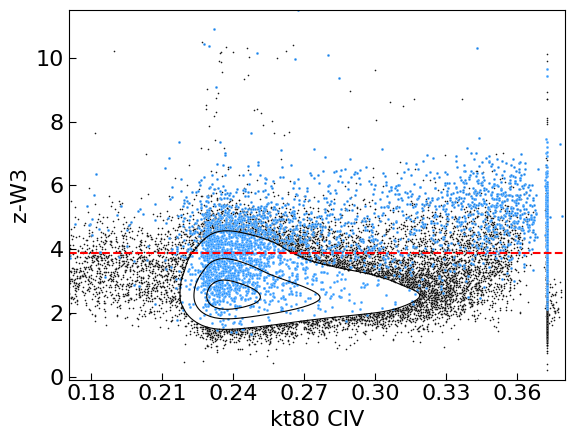

In [ ]:
fig, ax = plt.subplots()

contour_scatter_plot_v2(kt80_df[(kt80_df["accept_two_civ"]==True)],x="kt80_civ",y="z-w3",x_label="kt80 CIV",y_label="z-W3",subsample_col="rew_civ",subsample_cutoff=100,ax=ax,threshold_color="red",subsample_color="DodgerBlue",second_df=kt80_df[kt80_df["accept_two_civ"]==False],upper_x_lim=0.38)

# xlabels = ax.get_xticks()
# xticks = [int(x) if x==int(x) else x for x in xlabels]
# ax.set_xticklabels(xticks)
axes[0,0].set_xticks([0.18, 0.21, 0.24, 0.27, 0.3, 0.33, 0.36])

In [ ]:
0.37,0.33,0.29,0.25,0.21,0.16

In [65]:
xticks = list(reversed([0.37,0.34,0.31,0.28,0.25,0.22,0.19]))

In [69]:
[x-0.01 for x in xticks]

[0.18, 0.21, 0.24, 0.27, 0.3, 0.33, 0.36]

In [ ]:
2==

False

In [112]:
int(1.5)

1

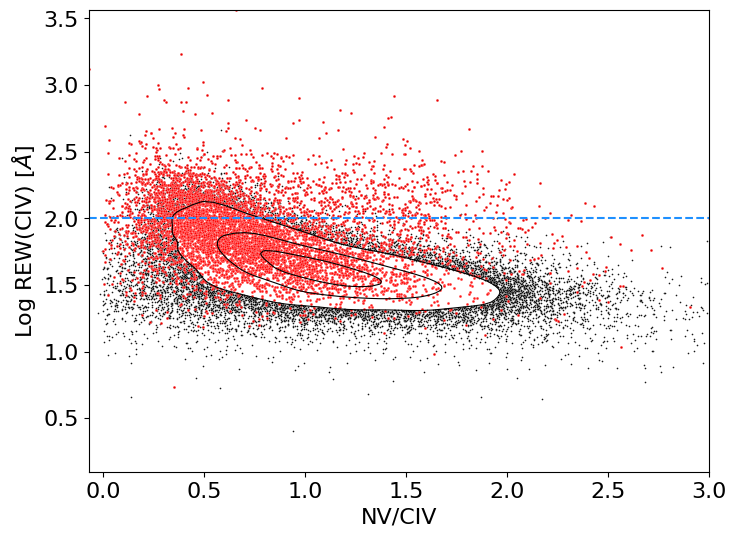

In [17]:
contour_scatter_plot(w3_copy_df[(np.isfinite(w3_copy_df["rew_civ_log"]))],x="nv/civ",y="rew_civ_log",upper_x_lim=3,x_label="NV/CIV",y_label=r"Log REW(CIV) [$\AA$]",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=2,y_threshold_label="Core ERQ threshold")

#### NV/Lya vs color

In [52]:
w3_copy_df.query("flux_lya>0 & flux_nv>0").groupby("Sample")["nv/lya"].describe().T

Sample,REW(CIV) > 100,W3 detected
count,3444.000000,40162.000000
mean,0.636569,1.371733
std,1.091057,11.961557
min,0.004542,0.000929
25%,0.314275,0.541362
50%,0.487100,0.836956
75%,0.741465,1.269607
max,53.837090,1876.691339


In [59]:
w3_copy_df[(w3_copy_df["flux_lya"]>0) & (w3_copy_df["flux_nv"]>0) & (w3_copy_df["z-w3"]>3.9)]["nv/lya"].describe().T

count    6375.000000
mean        0.892774
std         6.519884
min         0.001274
25%         0.335118
50%         0.557107
75%         0.886486
max       495.254820
Name: nv/lya, dtype: float64

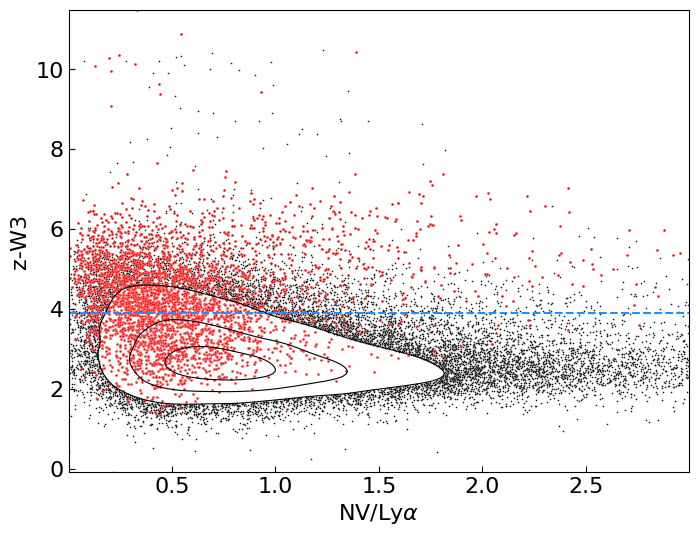

In [122]:
contour_scatter_plot(w3_copy_df[(w3_copy_df["flux_lya"]>0) & (w3_copy_df["flux_nv"]>0) & (w3_copy_df["nv/lya"]<3)],x="nv/lya",y="z-w3",x_label=r"NV/Ly$\alpha$",y_label="z-W3")

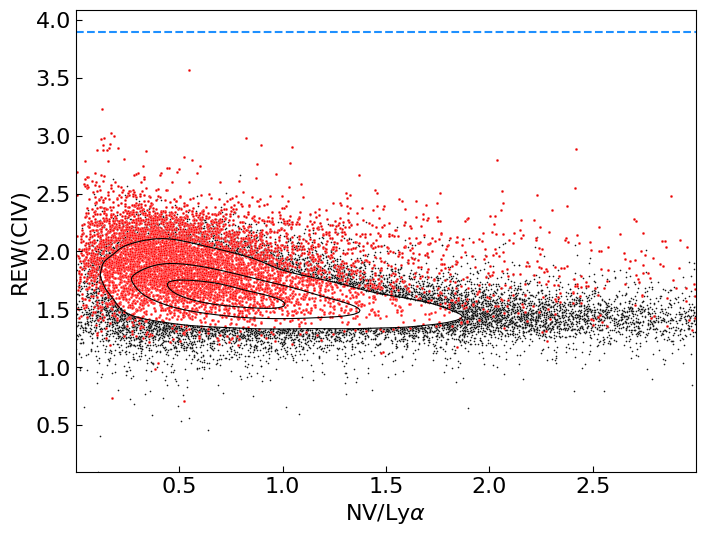

In [ ]:
contour_scatter_plot(w3_copy_df[(w3_copy_df["flux_lya"]>0) & (w3_copy_df["flux_nv"]>0) & (w3_copy_df["nv/lya"]<3) & (np.isfinite(w3_copy_df["rew_civ_log"]))],x="nv/lya",y="rew_civ_log",x_label=r"NV/Ly$\alpha$",y_label="REW(CIV)",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=2)

#### kt80 vs color

In [ ]:
# kt80_vs_color_df = w3_copy_df[w3_copy_df["kt80_civ"].notna()][["kt80_civ","z-w3"]].copy()

# k = kt80_vs_color_df[["kt80_civ","z-w3"]].values.T
# kde_kt80_vs_color = gaussian_kde(k)
# kt80_vs_color_df["density"] = kde_kt80_vs_color(k)

In [78]:
(kt80_df["accept_two_civ"]==False).mean()

0.15229789458675919

In [112]:
from scipy import stats

# your subsample data
subsample = kt80_df[(kt80_df['z-w3']>3.9)&(kt80_df['rew_civ']>100)]['kt80_civ'].values  # your data points

# population mean (the fixed reference value)
pop_mean = full["kt80_civ"].mean()  # e.g. 50.2

# one-sample t-test
t_stat, p_value = stats.ttest_1samp(subsample, pop_mean)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference from population mean")
else:
    print("No significant difference")

t-statistic: 18.3608
p-value: 0.0000
Significant difference from population mean


In [110]:
pop_mean

0.2696622097029459

In [111]:
subsample.mean()

0.27787189310598803

In [79]:
kt80_df.accept_two_civ.value_counts()

accept_two_civ
True     35673
False     6409
Name: count, dtype: int64

In [98]:
print(f"Mean kt80 value of CIV profiles\nFull sample:\t{full['kt80_civ'].mean():.3f}\nW3 detected:\t{full[full['snr_w3']>3]['kt80_civ'].mean():.3f}\nERQs:\t\t{kt80_df[kt80_df['z-w3']>3.9]['kt80_civ'].mean():.3f}\nCore ERQ:\t{kt80_df[(kt80_df['z-w3']>3.9)&(kt80_df['rew_civ']>100)]['kt80_civ'].mean():.3f}\nREW(CIV)>100:\t{kt80_df[(kt80_df['rew_civ']>100)&(kt80_df['rew_civ']>100)]['kt80_civ'].mean():.3f}")

Mean kt80 value of CIV profiles
Full sample:	0.270
W3 detected:	0.278
ERQs:		0.284
Core ERQ:	0.292
REW(CIV)>100:	0.281


In [96]:
print(f"Fraction of quasars with 'wingless' (kt80 > 0.33) CIV profiles\nFull sample:\t{(full['kt80_civ']>0.33).mean():.3f}\nW3 detected:\t{(full[full['snr_w3']>3]['kt80_civ']>0.33).mean():.3f}\nERQs:\t\t{(kt80_df[kt80_df['z-w3']>3.9]['kt80_civ']>0.33).mean():.3f}\nCore ERQ:\t{(kt80_df[(kt80_df['z-w3']>3.9)&(kt80_df['rew_civ']>100)]['kt80_civ']>0.33).mean():.3f}\nREW(CIV)>100:\t{(kt80_df[(kt80_df['rew_civ']>100)&(kt80_df['rew_civ']>100)]['kt80_civ']>0.33).mean():.3f}")

Fraction of quasars with 'wingless' (kt80 > 0.33) CIV profiles
Full sample:	0.155
W3 detected:	0.194
ERQs:		0.283
Core ERQ:	0.342
REW(CIV)>100:	0.258


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde


def contour_scatter_plot_v2(df,x,y="z-w3",y_threshold=3.9,y_threshold_label="ERQ threshold",subsample_col="rew_civ",subsample_cutoff=100,contour_levels=[25,55,85],figsize=(8,6),x_label=None,y_label=None,lower_x_lim=None,upper_x_lim=None,save_path=None,x_log=False,y_log=False,ax=None,subsample_color="red",threshold_color="DodgerBlue",second_df=None):
    density_df = df[[x,y]].copy()

    coords = density_df.values.T
    kde = gaussian_kde(coords)
    density_df["density"] = kde(coords)

    scatter_cutoff = np.percentile(density_df["density"],contour_levels[0])

    scatter_part = density_df[density_df["density"] < scatter_cutoff]
    # contour_part = density_df[density_df["density"] >= scatter_cutoff]

    x_vals = density_df[x].values
    y_vals = density_df[y].values

    xx, yy = np.mgrid[x_vals.min():x_vals.max():200j, y_vals.min():y_vals.max():200j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    grid_density = kde(positions).reshape(xx.shape)

    ## PLOTTING
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    ax.contour(xx, yy, grid_density, levels=[np.percentile(density_df["density"], val) for val in contour_levels], colors="black", linewidths=0.8)
    sns.scatterplot(data=scatter_part,x=x,y=y,s=1.5,alpha=0.9,ax=ax,color="black")

    sns.scatterplot(data=second_df[second_df[subsample_col]<=subsample_cutoff],x=x,y=y,color="black",s=1.5,ax=ax,alpha=0.9)
    sns.scatterplot(data=second_df[second_df[subsample_col]>subsample_cutoff],x=x,y=y,color=subsample_color,s=4,ax=ax,alpha=0.9)

    if subsample_col is not None:
        temp = df[df[subsample_col] > subsample_cutoff]
        sns.scatterplot(data=temp,x=x,y=y,s=4,alpha=0.9,ax=ax,color=subsample_color)

    if y_threshold is not None:
        ax.axhline(y_threshold,label=y_threshold_label,linestyle="--",color=threshold_color)

    ax.set_xlabel(x_label if x_label is not None else x)
    ax.set_ylabel(y_label if y_label is not None else y)

    if lower_x_lim is None:
        lower_x_lim, _ = ax.get_xlim()
    if upper_x_lim is None:
        _, upper_x_lim = ax.get_xlim()
    
    ax.set_xlim(lower_x_lim,upper_x_lim)

    if x_log:
        ax.set_xscale("log")
    if y_log:
        ax.set_yscale("log")

    if ax is None:
        plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path)
    
    # plt.plot()


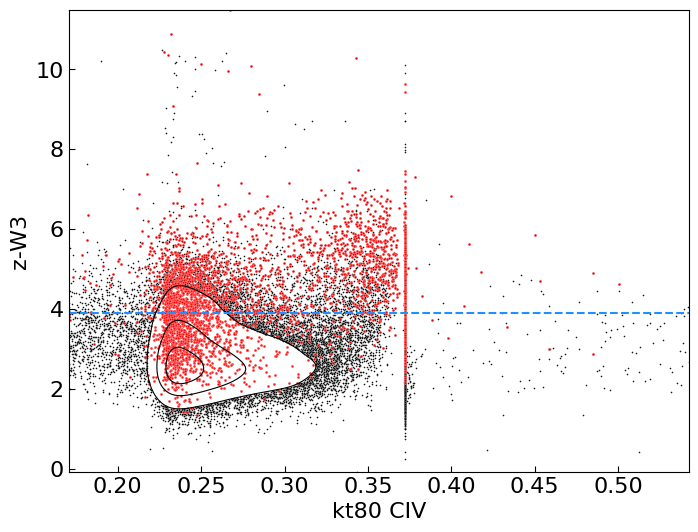

In [87]:
contour_scatter_plot_v2(kt80_df[kt80_df["accept_two_civ"]==True],x="kt80_civ",y="z-w3",x_label="kt80 CIV",y_label="z-W3",subsample_col="rew_civ",subsample_cutoff=100,second_df=kt80_df[kt80_df["accept_two_civ"]==False])

In [25]:
kt80_df["rew_civ_log"] = np.log10(kt80_df["rew_civ"].values)

/tmp/ipykernel_14362/3765453264.py:1: RuntimeWarning: divide by zero encountered in log10
  kt80_df["rew_civ_log"] = np.log10(kt80_df["rew_civ"].values)


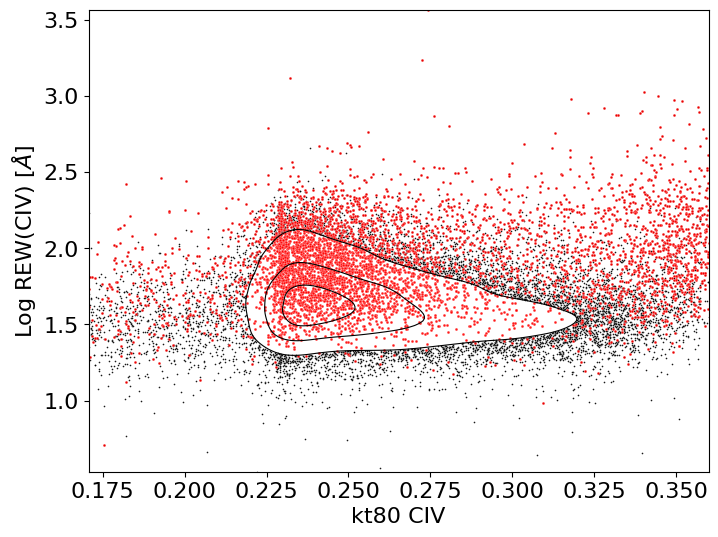

In [ ]:
# with pd.option_context('mode.use_inf_as_null', True):
contour_scatter_plot(kt80_df[(kt80_df["kt80_civ"]<0.36)&(np.isfinite(kt80_df["rew_civ_log"]))],x="kt80_civ",y="rew_civ_log",x_label="kt80 CIV",y_label=r"Log REW(CIV) [$\AA$]",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=100,y_threshold_label="Core ERQ threshold")

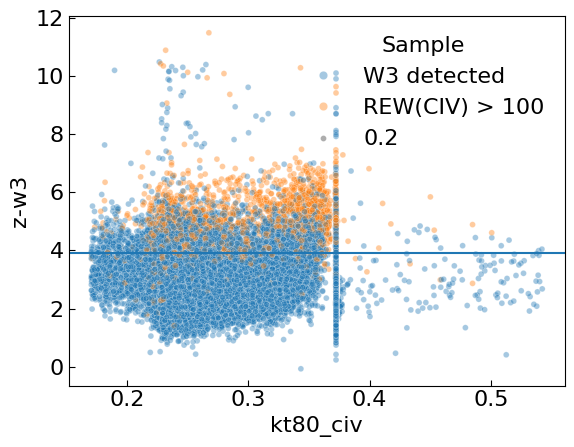

In [18]:
sns.scatterplot(data=kt80_df,x="kt80_civ",y="z-w3",hue="Sample",size=0.2,alpha=0.4)


plt.axhline(y=3.9)

# plt.xlim(-0.1,3.5)

<Axes: xlabel='kt80_civ', ylabel='Count'>

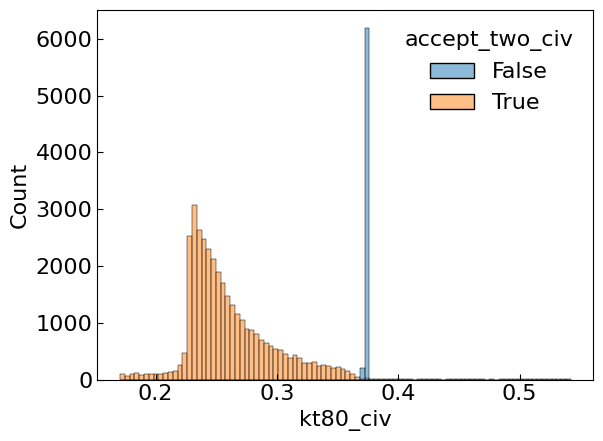

In [75]:
sns.histplot(data=kt80_df,x="kt80_civ",hue="accept_two_civ")

In [ ]:
sns.histplot(data=kt80_df[kt80_df[""]],x="kt80_civ")

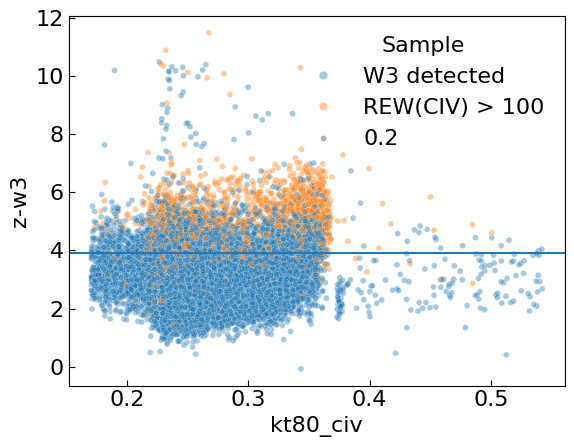

In [76]:
sns.scatterplot(data=kt80_df[kt80_df["accept_two_civ"]==True],x="kt80_civ",y="z-w3",hue="Sample",size=0.2,alpha=0.4)


plt.axhline(y=3.9)

# plt.xlim(-0.1,3.5)

#### Contour plot: z vs color

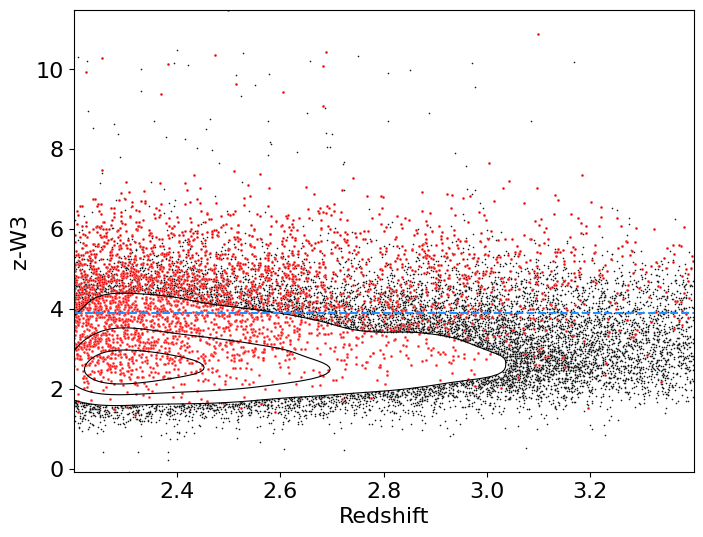

In [58]:
contour_scatter_plot(w3_copy_df,x="z",y="z-w3",x_label="Redshift",y_label="z-W3")

### Rejection reasons and absorption

In [76]:
details = pd.read_csv(DETAILS_PATH,index_col=1,dtype={"targetid":"str"}).drop(columns="Unnamed: 0")

In [77]:
for idx in details[details.index.isin(results.index)].index:
    results.loc[idx,"lya_blue"] = ast.literal_eval(details.loc[idx,"absorption_lya"])["blue_detected"]
    results.loc[idx,"lya_center"] = ast.literal_eval(details.loc[idx,"absorption_lya"])["center_detected"]
    results.loc[idx,"civ_blue"] = ast.literal_eval(details.loc[idx,"absorption_civ"])["blue_detected"]
    results.loc[idx,"civ_center"] = ast.literal_eval(details.loc[idx,"absorption_civ"])["center_detected"]

/tmp/ipykernel_20448/3815583446.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results.loc[idx,"lya_blue"] = ast.literal_eval(details.loc[idx,"absorption_lya"])["blue_detected"]
/tmp/ipykernel_20448/3815583446.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results.loc[idx,"lya_center"] = ast.literal_eval(details.loc[idx,"absorption_lya"])["center_detected"]
/tmp/ipykernel_20448/3815583446.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results.loc[idx,"civ_blue"] = ast.lit

In [207]:
print(f'Absorption:\nLya blue:\t{results["lya_blue"].mean():.3f}\nLya center:\t{results["lya_center"].mean():.3f}\nCIV blue:\t{results["civ_blue"].mean():.3f}\nCIV center:\t{results["civ_center"].mean():.3f}')

Absorption:
Lya blue:	0.213
Lya center:	0.560
CIV blue:	0.064
CIV center:	0.066


In [78]:
CIV_BLUESHIFT_PATH = "data/civ_blueshift_vals.csv"

shifts = pd.read_csv(CIV_BLUESHIFT_PATH,index_col=0,dtype={"targetid":"str"})
results = results.merge(shifts, left_index=True, right_index=True)

In [41]:
results

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fwhm_nv,fwhm_lya,kt80_civ,lya_blue,lya_center,civ_blue,civ_center,civ_shift_vel_raw,lya_shift_vel_raw,shift_diff
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,3251.881116,2260.575301,0.249399,False,True,False,False,-200.973573,-12.854863,-188.118710
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,4996.055063,2496.704981,0.238525,True,False,False,False,-78.657212,-13.598998,-65.058213
39627901502489216,61.661126,50.066402,56.991357,0.736838,6.510926,4.934822,8.353253,0.962441,0.832898,0.150371,...,5387.128039,4360.419360,0.234584,False,False,False,False,-27.595381,-692.461667,664.866285
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,6992.688130,3046.948259,0.324565,False,True,False,True,-2161.153402,1100.530091,-3261.683494
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,7353.267331,4962.357216,0.226158,False,False,False,False,-15.813154,289.497090,-305.310245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628053415987103,118.962903,49.831986,92.167040,0.680706,2.613462,0.727741,1.646045,0.920596,0.889807,0.038240,...,4535.865791,4139.097371,0.231864,False,False,False,False,81.070946,-454.343573,535.414519
39627983115257786,52.601683,27.833232,38.173872,0.953028,8.233751,6.199389,12.435801,0.997835,0.828916,0.280892,...,6737.115628,5221.039957,0.242868,False,False,False,False,-984.622413,97.382801,-1082.005214
39627926517322439,88.433732,33.716419,139.284764,0.519953,12.028317,5.543115,18.376339,0.950108,0.840580,0.050119,...,2341.278198,2033.014791,0.270749,False,True,False,False,-228.449335,80.035645,-308.484980


In [ ]:
results[(results["z-w3"]>3.9) & (results["rew_civ"]>100)]["shift_diff"].describe()

count     4848.000000
mean      -188.380575
std       2002.041841
min     -10599.722707
25%       -438.468456
50%       -151.621394
75%        140.258854
max      16882.999038
Name: shift_diff, dtype: float64

In [203]:
((results[(results["z"]>2) & (results["z"]<3.4) & (results["z-w3"]>3.9) & (results["rew_civ"]>100)]["shift_diff"]<-2500)).mean()

0.04850183229144212

In [200]:
((results[(results["z"]>2) & (results["z"]<3.4)]["z-w3"]>3.9) & (results[(results["z"]>2) & (results["z"]<3.4)]["rew_civ"]>100) & (results[(results["z"]>2) & (results["z"]<3.4)]["shift_diff"]<-2500)).mean()

0.00126799138892959

In [197]:
results[(results["z"]>2) & (results["z"]<3.4) & (results["z-w3"]>3.9) & (results["rew_civ"]>100) & (results["shift_diff"]<-2500)].describe()

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,civ_shift_vel_raw,lya_shift_vel_raw,shift_diff
count,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,...,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,218.000000,225.000000,225.000000,225.000000
mean,158.353864,175.001219,124.785108,0.660413,4.693051,4.253111,3.509758,0.916219,0.866116,0.036232,...,138.711210,150.169564,105.082831,4536.051061,4532.099084,4838.904478,0.303709,-1878.743076,3431.565974,-5310.309050
std,74.189283,154.325111,111.436963,0.126426,2.772727,3.595888,1.921045,0.041913,0.034746,0.044167,...,89.993215,150.895957,77.641549,2642.890050,2636.818813,4418.073394,0.056539,2382.116036,2522.621155,1449.693682
min,100.095962,1.247959,4.497970,0.421061,2.500469,0.536857,0.739705,0.732057,0.712719,0.002733,...,18.280357,1.020837,7.020192,1404.670758,1406.512605,1742.851084,0.211319,-9430.209692,-1421.351310,-10599.722707
25%,117.510257,54.918386,70.277829,0.571050,2.954536,1.486723,2.281386,0.890443,0.851240,0.013559,...,86.180389,60.803856,58.806723,2622.295530,2622.819104,2253.531120,0.244283,-2991.679174,358.965947,-6098.355398
50%,136.632147,155.930924,104.385691,0.640040,3.789282,3.219253,3.037674,0.916473,0.871495,0.024668,...,115.252466,114.064507,88.561289,3603.982528,3600.771057,3258.495066,0.313084,-691.971090,4787.458861,-5571.058802
75%,168.532025,240.498792,148.413016,0.737816,5.052017,5.906857,4.308317,0.949580,0.890443,0.042475,...,153.402102,188.721892,130.611828,5680.859684,5671.466762,5245.903378,0.356930,-141.168379,5691.104960,-4507.903609
max,795.489634,1363.986792,1274.601928,1.135122,23.490419,21.993353,10.785082,1.000000,0.936275,0.509966,...,669.702894,1312.237074,540.098245,17291.890922,17263.087991,23479.966431,0.484890,1311.065023,6028.515659,-2541.921878


In [210]:
((results["z"]>2) & (results["z"]<3.4) & ((results["civ_center"]==True) | (results["civ_blue"]==True))).mean()

0.11596661137567553

In [212]:
((results["z"]>2) & (results["z"]<3.4) & ((results["civ_center"]==True) | (results["civ_blue"]==True)) & (results["z-w3"]>3.9) & (results["rew_civ"]>100)).mean()

0.0012306704478570283

In [73]:
details[details.index.isin(results.index)].loc[str(39628528513191306),"absorption_civ"]

"{'intervals': [[1538.4089112500844, 1543.2723968151813]], 'blue_detected': False, 'center_detected': True}"

/tmp/ipykernel_20448/2030936219.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ylabels)


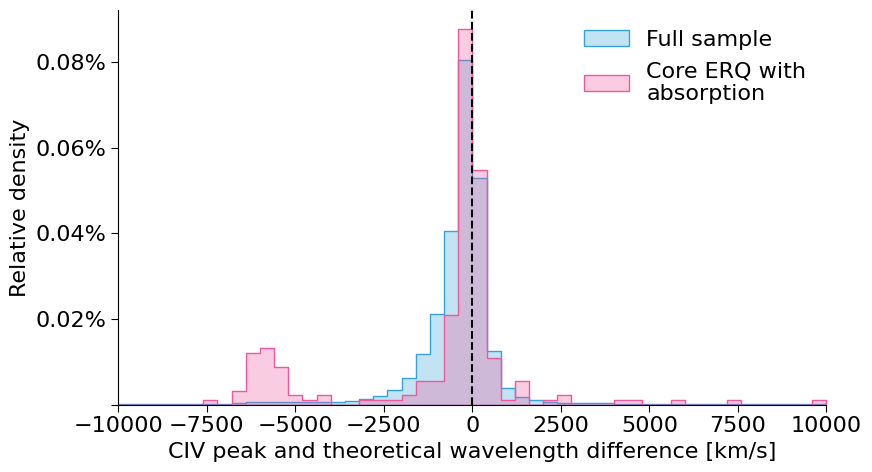

In [80]:
fig, ax = plt.subplots(figsize=(9,5))

sns.histplot(results[(results["z"]>2) & (results["z"]<3.4)]["shift_diff"],bins=50,stat="density",element="step",alpha=0.3,color=palette_dark[2],label="Full sample",ax=ax,binrange=(-10000,10000))

sns.histplot(results[(results["z"]>2) & (results["z"]<3.4) & ((results["civ_center"]==True) | (results["civ_blue"]==True)) &(results["z-w3"]>3.9) & (results["rew_civ"]>100)]["shift_diff"],bins=50,stat="density",element="step",alpha=0.3,color=palette_dark[0],label="Core ERQ with\nabsorption",ax=ax,binrange=(-10000,10000))


plt.axvline(0,color="black",linestyle="--")

ax.spines[['right', 'top']].set_visible(False)

yticks = ax.get_yticks()
ylabels = [""]+[str(round(y*100,2))+"%" for y in yticks[1:]]
ax.set_yticklabels(ylabels)

plt.xlabel(r"CIV peak and theoretical wavelength difference [km/s]")
plt.ylabel("Relative density")

plt.legend()

plt.xlim(-10000,10000)

plt.tight_layout()

plt.show()

/tmp/ipykernel_20448/1171148432.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ylabels)


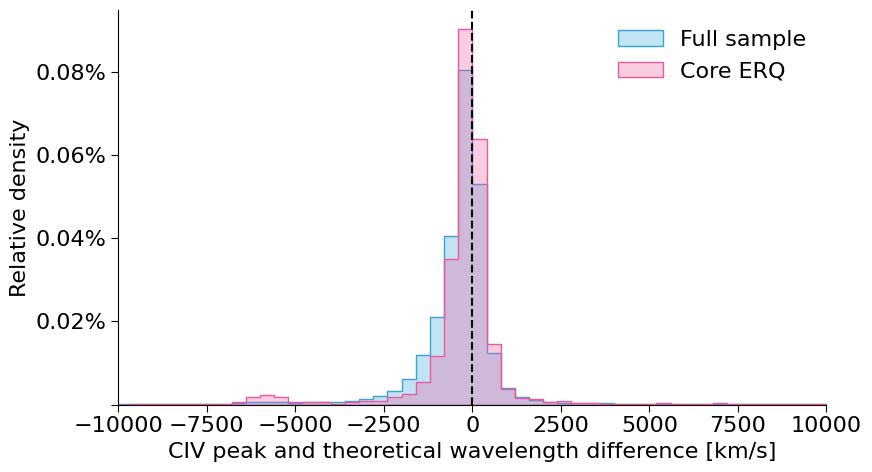

In [83]:
fig, ax = plt.subplots(figsize=(9,5))

sns.histplot(results[(results["z"]>2) & (results["z"]<3.4)]["shift_diff"],bins=50,stat="density",element="step",alpha=0.3,color=palette_dark[2],label="Full sample",ax=ax,binrange=(-10000,10000))

sns.histplot(results[(results["z"]>2) & (results["z"]<3.4) & (results["z-w3"]>3.9) & (results["rew_civ"]>100) ]["shift_diff"],bins=50,stat="density",element="step",alpha=0.3,color=palette_dark[0],label="Core ERQ",ax=ax,binrange=(-10000,10000))

plt.axvline(0,color="black",linestyle="--")

ax.spines[['right', 'top']].set_visible(False)

yticks = ax.get_yticks()
ylabels = [""]+[str(round(y*100,2))+"%" for y in yticks[1:]]
ax.set_yticklabels(ylabels)

plt.xlabel(r"CIV peak and theoretical wavelength difference [km/s]")
plt.ylabel("Relative density")

plt.legend()

plt.xlim(-10000,10000)

plt.tight_layout()

plt.show()